# RANSAC vs OLS / Ridge / Lasso / ElasticNet / Huber / Theil-Sen
### Robust Regression on Outlier-Contaminated Data

**What this notebook covers**

- Full derivation of the RANSAC iteration formula
- Step-by-step RANSAC implementation with adaptive-$N$ and verbose logging
- 7 regression methods fitted on the same dataset (**40 % outliers**):
  OLS · Ridge · Lasso · ElasticNet · Huber · Theil-Sen · RANSAC
- **Key insight:** regularisation (Ridge / Lasso / ElasticNet) does **not** fix
  outlier contamination — it only adds a parameter penalty. Only explicitly
  robust methods (Huber, Theil-Sen, RANSAC) recover the true line.
- 4-panel visualisation + metric bar charts

**Outputs**

- `01a_all_methods_lines.png` — scatter + 7 fitted lines
- `01b_metrics_comparison.png` — slope error / intercept error / MSE bars

In [1]:
import os
import warnings
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

warnings.filterwarnings("ignore")

OUT = os.getcwd()
rng = np.random.default_rng(42)

## Theory — The Seven Methods at a Glance

**OLS (Ordinary Least Squares)**
- Loss: $\sum (y_i - \hat y_i)^2$
- Breakdown point: **0 %** — a single large outlier can ruin the fit.
- Outlier robust: **NO**

**Ridge (L2 regularisation)**
- Loss: $\sum (y_i - \hat y_i)^2 + \lambda \lVert \beta \rVert^2$
- Adds a penalty that shrinks coefficients toward zero. Helps with
  multicollinearity and overfitting in high-dimensional settings. Does **not**
  change the treatment of outliers — it still minimises squared residuals.
- Outlier robust: **NO**

**Lasso (L1 regularisation)**
- Loss: $\sum (y_i - \hat y_i)^2 + \lambda \lVert \beta \rVert_1$
- Drives some coefficients to exactly zero (feature selection). Same squared
  data term as OLS — outliers still dominate.
- Outlier robust: **NO**

**ElasticNet (L1 + L2)**
- Loss: $\sum (y_i - \hat y_i)^2 + \lambda_1 \lVert \beta \rVert_1 + \lambda_2 \lVert \beta \rVert^2$
- Combines Ridge and Lasso. Still a squared data term.
- Outlier robust: **NO**

**Huber Regression**
- Loss: $\sum \rho(r_i)$, where
$$\rho(r) = \begin{cases} r^2/2 & |r| \le \varepsilon \\ \varepsilon|r| - \varepsilon^2/2 & |r| > \varepsilon \end{cases}$$
- Transitions from squared (small residuals) to **linear** (large ones). Large
  residuals contribute linearly, not quadratically → less pull.
  Breakdown point $\approx 50\%$ under ideal conditions.
- Outlier robust: **PARTIAL** (soft down-weighting, not hard rejection)

**Theil-Sen Estimator**
- Slope = **median** of slopes between all pairs of points;
  intercept $= \mathrm{median}(y_i - \text{slope} \cdot x_i)$.
- Breakdown point $\approx 29.3\%$ (exact) — immune to that fraction of
  arbitrary outliers regardless of their magnitude. Complexity $O(n^2)$ pairs.
- Outlier robust: **YES** (up to ~29 % outliers)

**RANSAC**
- Iteratively samples minimal subsets, scores consensus, keeps the hypothesis
  with the most inliers. Breakdown point up to $(1 - s/n) \approx 100\%$ with
  enough iterations. With $s=2$ on $n=200$: handles up to ~99 % outliers in
  principle.
- Outlier robust: **YES** (hard rejection of outliers)

### RANSAC $N$ Formula

With $p$ = desired success probability (e.g. 0.99), $\varepsilon$ = outlier
ratio, and $s$ = minimal sample size (2 for a line):

$$N \ge \frac{\log(1-p)}{\log\!\left(1 - (1-\varepsilon)^s\right)}$$

## Data Generation

Same seed for a fair comparison. We build a line $y = 1.5x + 2.0$ with 60 %
inliers (Gaussian noise) and 40 % outliers (uniform random $y$).

In [2]:
N_PTS         = 200
INLIER_RATIO  = 0.60     # 40 % outliers
SIGMA         = 0.3      # Gaussian noise on inliers

TRUE_SLOPE     = 1.5
TRUE_INTERCEPT = 2.0

x_all   = rng.uniform(0, 10, N_PTS)
y_clean = TRUE_SLOPE * x_all + TRUE_INTERCEPT

n_inliers  = int(N_PTS * INLIER_RATIO)
n_outliers = N_PTS - n_inliers

y_all = y_clean.copy()
y_all[:n_inliers] += rng.normal(0, SIGMA, n_inliers)
y_all[n_inliers:]  = rng.uniform(0, 17, n_outliers)

# "Ground truth" inlier mask for clean MSE evaluation
true_inlier_mask = np.zeros(N_PTS, dtype=bool)
true_inlier_mask[:n_inliers] = True

## RANSAC Implementation (fully annotated)

The algorithm proceeds in six steps:

1. **SAMPLE** — draw $s=2$ points at random (minimal sample set)
2. **HYPOTHESISE** — fit an exact line through those 2 points
3. **CONSENSUS** — count points with perpendicular distance $< \tau$
4. **EVALUATE** — save if this is the best consensus so far
5. **ADAPT** — update the $N$ estimate from the current inlier fraction
6. **REFINE** — refit with OLS on all final inliers

Perpendicular distance of a point to the line $y = mx + c$:
$$d = \frac{|m x - y + c|}{\sqrt{m^2 + 1}}$$

In [3]:
def ransac_line(x, y, s=2, p=0.99, tau=1.0, max_iter=1000, verbose=False):
    """Fit y = m*x + c using RANSAC."""
    n = len(x)

    best_m, best_c    = 0.0, 0.0
    best_inlier_mask  = np.zeros(n, dtype=bool)
    best_inlier_count = 0
    history           = []
    N_adapt           = max_iter

    for i in range(max_iter):

        # STEP 1 - SAMPLE
        idx      = rng.choice(n, 2, replace=False)
        x_s, y_s = x[idx], y[idx]

        # STEP 2 - HYPOTHESISE
        if np.abs(x_s[1] - x_s[0]) < 1e-10:
            continue
        m = (y_s[1] - y_s[0]) / (x_s[1] - x_s[0])
        c = y_s[0] - m * x_s[0]

        # STEP 3 - CONSENSUS
        # Perpendicular distance: |m*x - y + c| / sqrt(m^2+1)
        residuals    = np.abs(m * x - y + c) / np.sqrt(m**2 + 1)
        inlier_mask  = residuals < tau
        inlier_count = inlier_mask.sum()

        history.append((i + 1, inlier_count))

        # STEP 4 - EVALUATE
        if inlier_count > best_inlier_count:
            best_inlier_count = inlier_count
            best_m, best_c    = m, c
            best_inlier_mask  = inlier_mask.copy()

            # STEP 5 - ADAPTIVE N
            eps_hat = min(1.0 - inlier_count / n, 1.0 - 1e-9)
            p_clean = max((1.0 - eps_hat) ** s, 1e-9)
            N_adapt = int(np.ceil(np.log(1.0 - p) / np.log(1.0 - p_clean)))

            if verbose:
                print(f"  iter {i+1:4d}  inliers={inlier_count:4d}  "
                      f"eps_hat={eps_hat:.3f}  N_adapt={N_adapt}")

        if i >= N_adapt:
            if verbose:
                print(f"  Early stop at iter {i+1}  (N_adapt={N_adapt})")
            break

    # STEP 6 - REFINEMENT
    if best_inlier_mask.sum() >= 2:
        xi, yi = x[best_inlier_mask], y[best_inlier_mask]
        A      = np.column_stack([xi, np.ones_like(xi)])
        best_m, best_c = np.linalg.lstsq(A, yi, rcond=None)[0]
        residuals        = np.abs(best_m * x - y + best_c) / np.sqrt(best_m**2 + 1)
        best_inlier_mask = residuals < tau

    return best_m, best_c, best_inlier_mask, history

## Fit All Seven Methods

### 1. OLS

The plain least-squares baseline, solved via the normal equations.

In [4]:
A_full       = np.column_stack([x_all, np.ones(N_PTS)])
m_ols, c_ols = np.linalg.lstsq(A_full, y_all, rcond=None)[0]

### 2. Ridge (L2 regularisation, closed form)

Ridge adds $\lambda I$ to the normal equations: $\beta = (X^\top X + \lambda I)^{-1} X^\top y$.
On a 1-D problem with any reasonable $\lambda$ this is nearly identical to OLS,
because regularising a single slope coefficient barely changes the fit. The key
lesson: Ridge helps with multicollinearity / high dimensions, **not** with outliers.

In [5]:
def ridge_fit(x, y, lam=1.0):
    A = np.column_stack([x, np.ones_like(x)])
    # Normal equations with L2 penalty (exclude bias from penalty)
    AtA    = A.T @ A
    AtA[0, 0] += lam          # penalise slope only (standard ridge)
    Aty    = A.T @ y
    beta   = np.linalg.solve(AtA, Aty)
    return beta[0], beta[1]

m_ridge, c_ridge = ridge_fit(x_all, y_all, lam=1.0)

### 3. Lasso (L1 regularisation, coordinate descent)

Lasso replaces the L2 penalty with $\lambda |\beta|$, driving sparse solutions.
The data term is still $\sum (y_i - \hat y_i)^2$ — outliers dominate just like
OLS. We use coordinate descent with the soft-thresholding operator.

In [6]:
def lasso_fit(x, y, lam=0.5, max_iter=2000, tol=1e-6):
    A = np.column_stack([x, np.ones_like(x)])
    n, p  = A.shape
    beta  = np.zeros(p)
    r     = y.copy()

    for _ in range(max_iter):
        beta_old = beta.copy()
        for j in range(p):
            r_j    = r + A[:, j] * beta[j]    # partial residual
            rho    = A[:, j] @ r_j
            norm_j = A[:, j] @ A[:, j]
            if j == 0:                          # slope: apply L1 penalty
                beta[j] = np.sign(rho) * max(abs(rho) - lam, 0) / norm_j
            else:                               # intercept: no penalty
                beta[j] = rho / norm_j
            r = r_j - A[:, j] * beta[j]
        if np.max(np.abs(beta - beta_old)) < tol:
            break
    return beta[0], beta[1]

m_lasso, c_lasso = lasso_fit(x_all, y_all, lam=0.5)

### 4. ElasticNet (L1 + L2, coordinate descent)

ElasticNet combines both penalties: $\lambda_1 |\beta| + \lambda_2 \beta^2$. The
update rule adds an L2 shrinkage term to the soft-threshold step.

In [7]:
def elasticnet_fit(x, y, lam1=0.3, lam2=0.3, max_iter=2000, tol=1e-6):
    A = np.column_stack([x, np.ones_like(x)])
    n, p  = A.shape
    beta  = np.zeros(p)
    r     = y.copy()

    for _ in range(max_iter):
        beta_old = beta.copy()
        for j in range(p):
            r_j    = r + A[:, j] * beta[j]
            rho    = A[:, j] @ r_j
            norm_j = A[:, j] @ A[:, j] + lam2
            if j == 0:
                beta[j] = np.sign(rho) * max(abs(rho) - lam1, 0) / norm_j
            else:
                beta[j] = rho / norm_j
            r = r_j - A[:, j] * beta[j]
        if np.max(np.abs(beta - beta_old)) < tol:
            break
    return beta[0], beta[1]

m_enet, c_enet = elasticnet_fit(x_all, y_all, lam1=0.3, lam2=0.3)

### 5. Huber Regression (IRLS)

Huber loss:
$$\rho(r) = \begin{cases} r^2/2 & |r| \le \delta \\ \delta|r| - \delta^2/2 & |r| > \delta \end{cases}$$

Points in the linear zone get a **down-weighted** contribution, with weight
$w_i = \min(1, \delta / |r_i|)$. IRLS alternates between computing weights from
the current residuals and fitting a weighted least squares with those weights.
The transition is smooth (not hard rejection like RANSAC), so very large
outliers still contribute — just less than quadratically.

In [8]:
def huber_fit(x, y, delta=1.35, max_iter=100, tol=1e-6):
    A    = np.column_stack([x, np.ones_like(x)])
    beta = np.linalg.lstsq(A, y, rcond=None)[0]    # warm start from OLS

    for _ in range(max_iter):
        r     = y - A @ beta
        # Huber weights: w=1 inside the delta-band, w=delta/|r| outside
        w     = np.where(np.abs(r) <= delta, 1.0, delta / (np.abs(r) + 1e-10))
        W     = np.diag(w)
        AtWA  = A.T @ W @ A
        AtWy  = A.T @ W @ y
        beta_new = np.linalg.solve(AtWA, AtWy)
        if np.max(np.abs(beta_new - beta)) < tol:
            beta = beta_new
            break
        beta = beta_new

    return beta[0], beta[1]

m_huber, c_huber = huber_fit(x_all, y_all, delta=1.35)

### 6. Theil-Sen Estimator (median of pairwise slopes)

$$\text{slope} = \mathrm{median}\left\{ \frac{y_j - y_i}{x_j - x_i} : i < j \right\}, \qquad \text{intercept} = \mathrm{median}(y_i - \text{slope}\cdot x_i)$$

Breakdown point $\approx 29.3\%$ — immune to that fraction of arbitrary
outliers. Complexity $O(n^2)$ pairs; we sample a random subset of pairs for speed.

In [9]:
def theilsen_fit(x, y, max_pairs=5000):
    n = len(x)
    i_idx, j_idx = np.triu_indices(n, k=1)     # all pairs
    if len(i_idx) > max_pairs:                  # subsample for speed
        sel   = rng.choice(len(i_idx), size=max_pairs, replace=False)
        i_idx = i_idx[sel];  j_idx = j_idx[sel]

    dx = x[j_idx] - x[i_idx]
    mask = np.abs(dx) > 1e-10                   # avoid vertical pairs
    slopes = (y[j_idx[mask]] - y[i_idx[mask]]) / dx[mask]

    m = np.median(slopes)
    c = np.median(y - m * x)
    return m, c

m_theil, c_theil = theilsen_fit(x_all, y_all)

### 7. RANSAC

We set the inlier threshold to $\tau = 1.96\,\sigma$ (the 95 % band of the
inlier noise) and run with verbose logging to watch the adaptive early-stop.

In [10]:
TAU = 1.96 * SIGMA
print("=" * 65)
print("  RANSAC verbose log")
print("=" * 65)
m_ran, c_ran, ransac_mask, history = ransac_line(
    x_all, y_all, s=2, p=0.99, tau=TAU, max_iter=500, verbose=True
)

  RANSAC verbose log
  iter    1  inliers=  25  eps_hat=0.875  N_adapt=293
  iter    3  inliers= 135  eps_hat=0.325  N_adapt=8
  Early stop at iter 9  (N_adapt=8)


## Collect Results into a Comparison Table

In [11]:
methods = {
    #  name            slope        intercept    colour      linestyle  lw
    "OLS":        (m_ols,   c_ols,   "#3498db", "-",  2.0),
    "Ridge":      (m_ridge, c_ridge, "#9b59b6", "--", 1.8),
    "Lasso":      (m_lasso, c_lasso, "#1abc9c", "-.", 1.8),
    "ElasticNet": (m_enet,  c_enet,  "#f39c12", ":",  1.8),
    "Huber":      (m_huber, c_huber, "#e67e22", "--", 2.0),
    "Theil-Sen":  (m_theil, c_theil, "#8e44ad", "-",  2.0),
    "RANSAC":     (m_ran,   c_ran,   "#e74c3c", "-",  2.8),
}

print(f"\n  {'Method':<13}  {'Slope':>8}  {'Intercept':>10}  "
      f"{'D slope':>9}  {'D intercept':>12}")
print(f"  {'True':.<13}  {TRUE_SLOPE:>8.3f}  {TRUE_INTERCEPT:>10.3f}")
print(f"  {'-'*60}")
for name, (m, c, *_) in methods.items():
    dm = m - TRUE_SLOPE
    dc = c - TRUE_INTERCEPT
    print(f"  {name:<13}  {m:>8.3f}  {c:>10.3f}  "
          f"{dm:>+9.3f}  {dc:>+12.3f}")


  Method            Slope   Intercept    D slope   D intercept
  True.........     1.500       2.000
  ------------------------------------------------------------
  OLS               1.046       4.216     -0.454        +2.216
  Ridge             1.045       4.220     -0.455        +2.220
  Lasso             1.045       4.218     -0.455        +2.218
  ElasticNet        1.049       4.193     -0.451        +2.193
  Huber             1.397       2.547     -0.103        +0.547
  Theil-Sen         1.437       2.333     -0.063        +0.333
  RANSAC            1.496       2.071     -0.004        +0.071


## Metrics — Evaluated on the True Inliers Only (clean MSE)

We evaluate each method on the known inlier points only. This is the "oracle"
test: given the true underlying relationship, how well did each method recover it?

In [12]:
x_in = x_all[true_inlier_mask]
y_in = y_all[true_inlier_mask]

def mse_on_inliers(m, c):
    y_hat = m * x_in + c
    return np.mean((y_hat - y_in) ** 2)

def slope_err(m):
    return abs(m - TRUE_SLOPE)

def intercept_err(c):
    return abs(c - TRUE_INTERCEPT)

print(f"\n  {'Method':<13}  {'|D slope|':>10}  {'|D intercept|':>14}  "
      f"{'MSE (inliers)':>14}")
print(f"  {'-'*57}")
mse_scores = {}
for name, (m, c, *_) in methods.items():
    mse = mse_on_inliers(m, c)
    mse_scores[name] = mse
    print(f"  {name:<13}  {slope_err(m):>10.4f}  {intercept_err(c):>14.4f}  "
          f"{mse:>14.4f}")


  Method          |D slope|   |D intercept|   MSE (inliers)
  ---------------------------------------------------------
  OLS                0.4543          2.2163          1.7882
  Ridge              0.4550          2.2196          1.7929
  Lasso              0.4547          2.2179          1.7904
  ElasticNet         0.4508          2.1926          1.7639
  Huber              0.1029          0.5469          0.2078
  Theil-Sen          0.0632          0.3332          0.1443
  RANSAC             0.0039          0.0714          0.0961


## Figure 1 — All Methods on the Scatter Plot

Three panels: the fitted lines over the data, the RANSAC inlier-count history,
and the residual distributions per method.

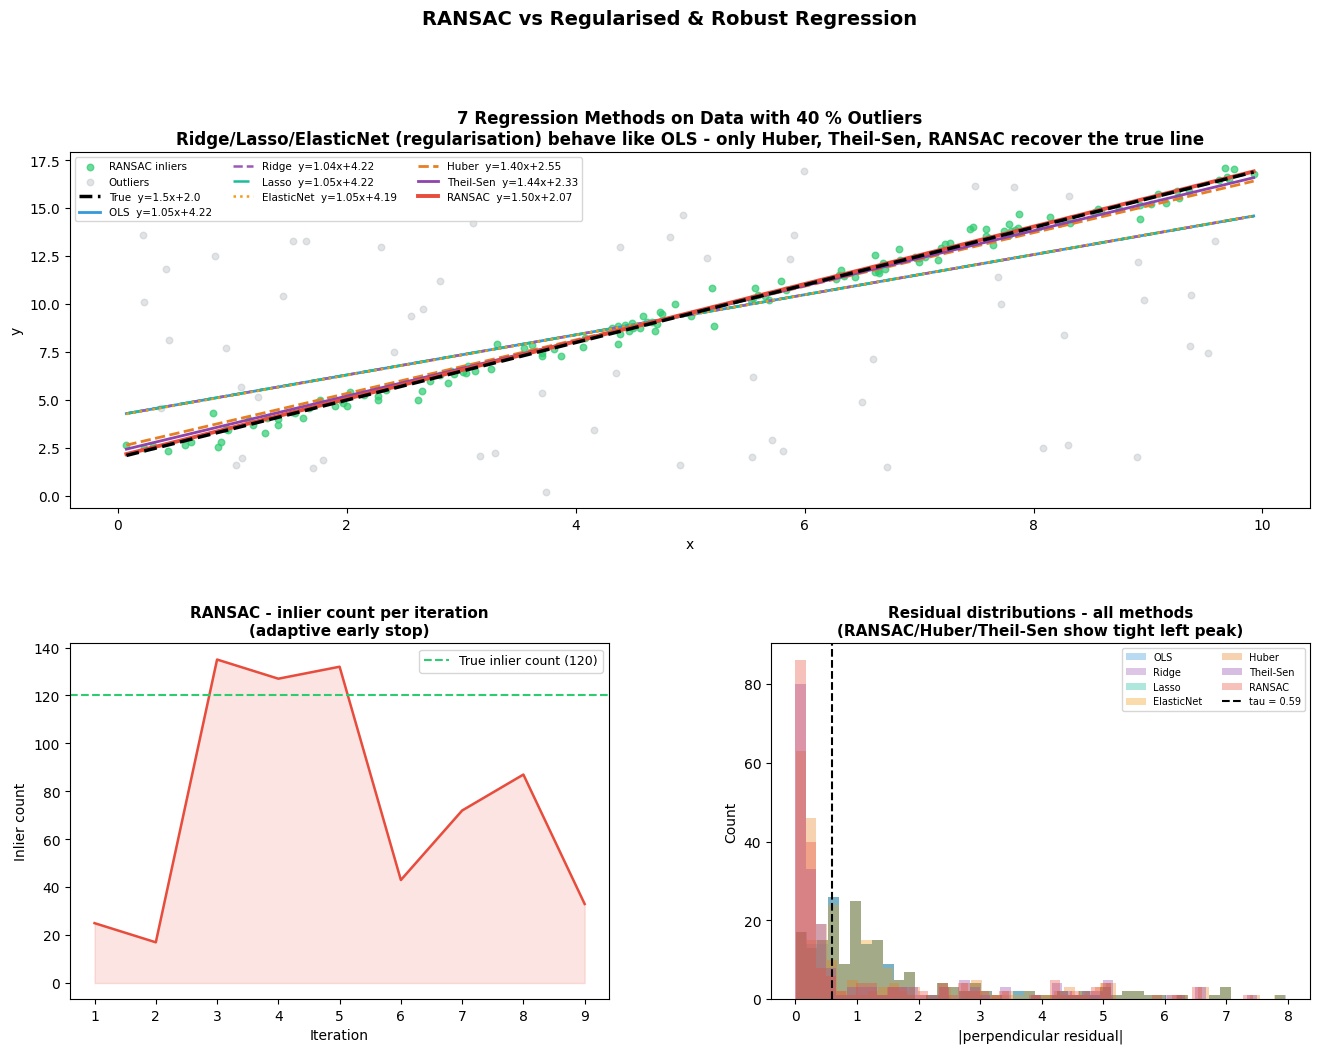


  saved  01a_all_methods_lines.png


In [13]:
fig = plt.figure(figsize=(16, 11))
gs  = GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.30)

# Panel 1 (top, full width): scatter + all fitted lines
ax1 = fig.add_subplot(gs[0, :])

ax1.scatter(x_all[ransac_mask],  y_all[ransac_mask],
            c="#2ecc71", s=22, alpha=0.7,
            label="RANSAC inliers", zorder=3)
ax1.scatter(x_all[~ransac_mask], y_all[~ransac_mask],
            c="#bdc3c7", s=22, alpha=0.45,
            label="Outliers", zorder=2)

xp = np.array([x_all.min(), x_all.max()])

# True line
ax1.plot(xp, TRUE_SLOPE * xp + TRUE_INTERCEPT,
         "k--", lw=2.5, label=f"True  y={TRUE_SLOPE}x+{TRUE_INTERCEPT}",
         zorder=6)

# All seven methods
for name, (m, c, col, ls, lw) in methods.items():
    ax1.plot(xp, m * xp + c, color=col, lw=lw, ls=ls,
             label=f"{name}  y={m:.2f}x+{c:.2f}", zorder=5)

ax1.set_title(
    f"7 Regression Methods on Data with {n_outliers/N_PTS*100:.0f} % Outliers\n"
    f"Ridge/Lasso/ElasticNet (regularisation) behave like OLS - "
    f"only Huber, Theil-Sen, RANSAC recover the true line",
    fontsize=12, fontweight="bold",
)
ax1.legend(fontsize=7.5, ncol=3, loc="upper left")
ax1.set_xlabel("x");  ax1.set_ylabel("y")

# Panel 2 (bottom-left): RANSAC iteration history
ax2 = fig.add_subplot(gs[1, 0])

iters, counts = zip(*history)
ax2.plot(iters, counts, lw=1.8, color="#e74c3c")
ax2.fill_between(iters, counts, alpha=0.15, color="#e74c3c")
ax2.axhline(n_inliers, color="#2ecc71", ls="--", lw=1.5,
            label=f"True inlier count ({n_inliers})")
ax2.set_title("RANSAC - inlier count per iteration\n(adaptive early stop)",
              fontsize=11, fontweight="bold")
ax2.set_xlabel("Iteration");  ax2.set_ylabel("Inlier count")
ax2.legend(fontsize=9)

# Panel 3 (bottom-right): residual histograms
ax3 = fig.add_subplot(gs[1, 1])

for name, (m, c, col, ls, lw) in methods.items():
    res = np.abs(m * x_all - y_all + c) / np.sqrt(m**2 + 1)
    ax3.hist(res, bins=45, alpha=0.35, color=col, label=name)

ax3.axvline(TAU, color="k", ls="--", lw=1.5, label=f"tau = {TAU:.2f}")
ax3.set_title("Residual distributions - all methods\n"
              "(RANSAC/Huber/Theil-Sen show tight left peak)",
              fontsize=11, fontweight="bold")
ax3.set_xlabel("|perpendicular residual|");  ax3.set_ylabel("Count")
ax3.legend(fontsize=7, ncol=2)

fig.suptitle("RANSAC vs Regularised & Robust Regression",
             fontsize=14, fontweight="bold", y=1.01)

path = os.path.join(OUT, "01a_all_methods_lines.png")
fig.savefig(path, dpi=140, bbox_inches="tight")
plt.show()
print(f"\n  saved  01a_all_methods_lines.png")

## Figure 2 — Metric Bar Charts

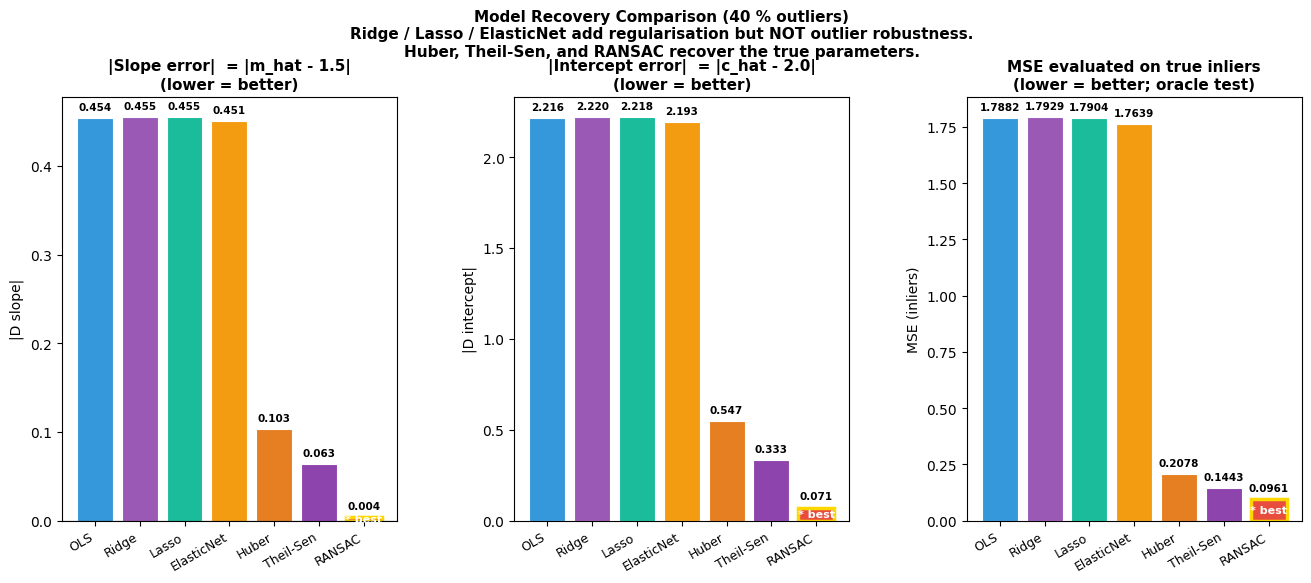

  saved  01b_metrics_comparison.png


In [14]:
names   = list(methods.keys())
colors  = [v[2] for v in methods.values()]
slopes  = [slope_err(v[0])     for v in methods.values()]
inters  = [intercept_err(v[1]) for v in methods.values()]
mses    = [mse_scores[n]       for n in names]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.subplots_adjust(wspace=0.35)

x_pos = np.arange(len(names))
bar_kw = dict(edgecolor="white", linewidth=0.8)

def annotate_bars(ax, bars, fmt="{:.3f}"):
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2,
                h + max([bb.get_height() for bb in bars]) * 0.015,
                fmt.format(h), ha="center", va="bottom",
                fontsize=7.5, fontweight="bold")

# |D slope|
ax = axes[0]
bars = ax.bar(x_pos, slopes, color=colors, **bar_kw)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(x_pos);  ax.set_xticklabels(names, rotation=30, ha="right", fontsize=9)
ax.set_title("|Slope error|  = |m_hat - 1.5|\n(lower = better)",
             fontsize=11, fontweight="bold")
ax.set_ylabel("|D slope|")
annotate_bars(ax, bars)
best_idx = int(np.argmin(slopes))
bars[best_idx].set_edgecolor("gold");  bars[best_idx].set_linewidth(2.5)
ax.text(x_pos[best_idx], slopes[best_idx] / 2, "* best",
        ha="center", va="center", fontsize=8, color="white", fontweight="bold")

# |D intercept|
ax2 = axes[1]
bars2 = ax2.bar(x_pos, inters, color=colors, **bar_kw)
ax2.set_xticks(x_pos);  ax2.set_xticklabels(names, rotation=30, ha="right", fontsize=9)
ax2.set_title("|Intercept error|  = |c_hat - 2.0|\n(lower = better)",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("|D intercept|")
annotate_bars(ax2, bars2)
best_idx2 = int(np.argmin(inters))
bars2[best_idx2].set_edgecolor("gold");  bars2[best_idx2].set_linewidth(2.5)
ax2.text(x_pos[best_idx2], inters[best_idx2] / 2, "* best",
         ha="center", va="center", fontsize=8, color="white", fontweight="bold")

# MSE on inliers
ax3 = axes[2]
bars3 = ax3.bar(x_pos, mses, color=colors, **bar_kw)
ax3.set_xticks(x_pos);  ax3.set_xticklabels(names, rotation=30, ha="right", fontsize=9)
ax3.set_title("MSE evaluated on true inliers\n(lower = better; oracle test)",
              fontsize=11, fontweight="bold")
ax3.set_ylabel("MSE (inliers)")
annotate_bars(ax3, bars3, fmt="{:.4f}")
best_idx3 = int(np.argmin(mses))
bars3[best_idx3].set_edgecolor("gold");  bars3[best_idx3].set_linewidth(2.5)
ax3.text(x_pos[best_idx3], mses[best_idx3] / 2, "* best",
         ha="center", va="center", fontsize=8, color="white", fontweight="bold")

fig.suptitle(
    "Model Recovery Comparison (40 % outliers)\n"
    "Ridge / Lasso / ElasticNet add regularisation but NOT outlier robustness.\n"
    "Huber, Theil-Sen, and RANSAC recover the true parameters.",
    fontsize=11, fontweight="bold", y=1.04,
)

path = os.path.join(OUT, "01b_metrics_comparison.png")
fig.savefig(path, dpi=140, bbox_inches="tight")
plt.show()
print(f"  saved  01b_metrics_comparison.png")

## Key Insight

Regularisation (Ridge / Lasso / ElasticNet) penalises model complexity — it does
**not** change how residuals are handled. The data term is still
$\sum (y_i - \hat y_i)^2$, so a large outlier with residual $10\sigma$ still
contributes $100\sigma^2$ to the loss, dwarfing all genuine inliers combined.

Only methods that modify the **loss on individual residuals** (Huber) or use
**order / consensus statistics** (Theil-Sen, RANSAC) are truly robust to outlier
contamination.

In [15]:
best_name  = min(mse_scores, key=mse_scores.get)
worst_name = max(mse_scores, key=mse_scores.get)
print(f"  Best  method by inlier MSE : {best_name}  ({mse_scores[best_name]:.4f})")
print(f"  Worst method by inlier MSE : {worst_name} ({mse_scores[worst_name]:.4f})")

  Best  method by inlier MSE : RANSAC  (0.0961)
  Worst method by inlier MSE : Ridge (1.7929)
